<a href="https://colab.research.google.com/github/syedayaan2712-lang/SYED-AYAAN-202501100300267/blob/main/Syed_Ayaan_202501100300267_casestudy2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Credit Card Fraud Detection

XGBoost with SMOTE, threshold tuning, and feature importance

## 1. Install libraries

In [1]:
!pip install xgboost imbalanced-learn -q

## 2. Import libraries

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

## 3. Create transaction data

In [ ]:
data = {
    "amount": [20, 50, 100, 10, 500, 30, 1000, 15, 70, 200, 25, 800, 40, 60, 900, 35, 120, 45, 700, 55],
    "time": [10, 12, 14, 15, 18, 20, 22, 25, 28, 30, 32, 35, 38, 40, 42, 45, 48, 50, 52, 55],
    "merchant_risk": [1, 1, 2, 1, 3, 1, 4, 1, 2, 2, 1, 4, 1, 2, 5, 1, 2, 1, 5, 2],
    "location_change": [0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0],
    "previous_transactions": [20, 30, 25, 40, 15, 35, 10, 50, 30, 20, 45, 8, 50, 40, 5, 55, 30, 45, 4, 35],
    "fraud": [0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0]
}

df = pd.DataFrame(data)
df

,amount,time,merchant_risk,location_change,previous_transactions,fraud
0,20,10,1,0,20,0
1,50,12,1,0,30,0
2,100,14,2,0,25,0
3,10,15,1,0,40,0
4,500,18,3,1,15,0
5,30,20,1,0,35,0
6,1000,22,4,1,10,1
7,15,25,1,0,50,0
8,70,28,2,0,30,0
9,200,30,2,1,20,0


## 4. Separate input and output

In [ ]:
X = df.drop("fraud", axis=1)
y = df["fraud"]

## 5. Split the data

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

## 6. Apply SMOTE

In [ ]:
smote = SMOTE(random_state=42, k_neighbors=2)
X_train, y_train = smote.fit_resample(X_train, y_train)

print(y_train.value_counts())

fraud
1    11
0    11
Name: count, dtype: int64


## 7. Create and train the XGBoost model

In [ ]:
model = XGBClassifier(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.1,
    random_state=42,
    eval_metric="logloss"
)

model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=3, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, ...)

## 8. Get fraud probabilities

In [ ]:
y_prob = model.predict_proba(X_test)[:, 1]
print(y_prob)

[0.09934315 0.9006568  0.09934315 0.09934315 0.09934315 0.09934315]


## 9. Evaluate using ROC-AUC

In [ ]:
auc = roc_auc_score(y_test, y_prob)
print("ROC-AUC:", auc)

ROC-AUC: 1.0


## 10. Tune the decision threshold

In [ ]:
threshold = 0.30
y_pred = (y_prob >= threshold).astype(int)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred, zero_division=0))

[[5 0]
 [0 1]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         5
           1       1.00      1.00      1.00         1

    accuracy                           1.00         6
   macro avg       1.00      1.00      1.00         6
weighted avg       1.00      1.00      1.00         6



A lower threshold can help detect more fraudulent transactions. The trade-off is that more normal transactions may be incorrectly marked as fraud.

## 11. Feature importance

In [ ]:
importance = pd.Series(model.feature_importances_, index=X.columns)
importance = importance.sort_values(ascending=False)
print(importance)

amount                   1.0
time                     0.0
merchant_risk            0.0
location_change          0.0
previous_transactions    0.0
dtype: float32


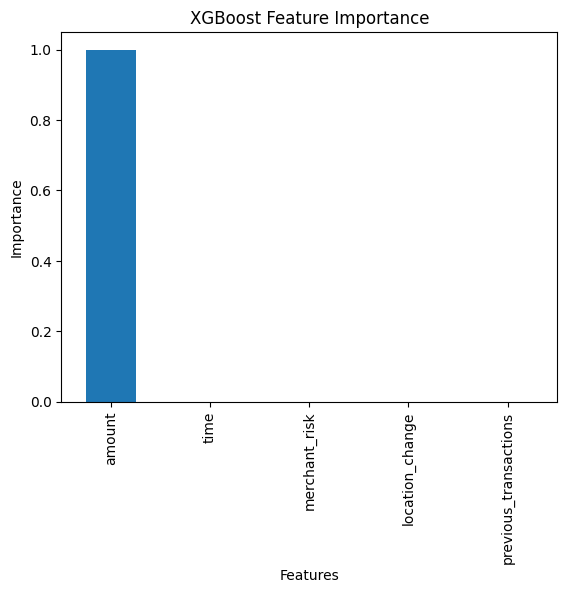

In [ ]:
importance.plot(kind="bar")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.title("XGBoost Feature Importance")
plt.show()

## Conclusion

XGBoost can be used to detect fraudulent transactions. SMOTE helps deal with the imbalanced training data by creating additional minority-class samples. Changing the decision threshold allows the model to focus more on detecting fraud. Feature importance scores show which transaction features were most useful to the model.

This small dataset is only for demonstration. A real fraud detection project should use a large dataset such as IEEE-CIS or another suitable transaction dataset and should evaluate the model with appropriate fraud detection metrics.